## Author: Gaurav Law - Case 2 Prosecution

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.





## 🩺 Case 2: Tumor Misclassification – Breast Cancer Dataset
#### 🔍 Scenario
Patient X received a benign classification from an AI tumor diagnostic tool and was not referred for a biopsy. Months later, the tumor was diagnosed as malignant. The model’s output is now under scrutiny.

#### 🟥 Prosecution
Use explanation tools to evaluate how the model arrived at this decision. Consider whether any key medical indicators might have been overlooked or minimized.

#### 🟦 Defense
Defend the decision with reference to the model’s logic and learned feature importance. Consider how this decision aligns with the broader data trends.

In [ ]:
# 🧬 Case 2: Tumor Misclassification (Breast Cancer Dataset)
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

#!pip install shap alibi
import shap

# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc["target"] = data.target  # 0 = malignant, 1 = benign

# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame(
    [
        {
            "mean radius": 13.80,
            "mean texture": 15.79,
            "mean perimeter": 90.43,
            "mean area": 584.1,
            "mean smoothness": 0.1007,
            "mean compactness": 0.1280,
            "mean concavity": 0.07789,
            "mean concave points": 0.05069,
            "mean symmetry": 0.1662,
            "mean fractal dimension": 0.06566,
            "radius error": 0.4101,
            "texture error": 1.074,
            "perimeter error": 2.635,
            "area error": 40.14,
            "smoothness error": 0.00541,
            "compactness error": 0.02204,
            "concavity error": 0.01664,
            "concave points error": 0.01185,
            "symmetry error": 0.02095,
            "fractal dimension error": 0.004902,
            "worst radius": 16.57,
            "worst texture": 20.86,
            "worst perimeter": 110.3,
            "worst area": 812.4,
            "worst smoothness": 0.1411,
            "worst compactness": 0.3542,
            "worst concavity": 0.2779,
            "worst concave points": 0.1383,
            "worst symmetry": 0.2589,
            "worst fractal dimension": 0.1030,
        }
    ]
)

# Run prediction
pred = model_bc.predict(focus_instance_bc)
print(
    "Prediction for Patient X:",
    "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed",
)

Prediction for Patient X: Benign → No Biopsy


## XAI Strategies

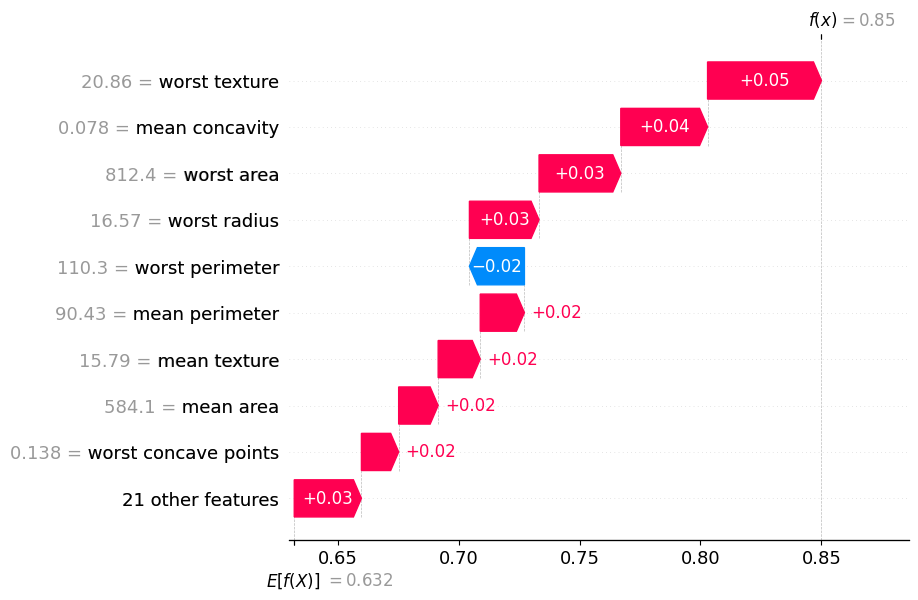

In [3]:
# TreeSHAP

explainer = shap.TreeExplainer(model_bc)
shap_values = explainer(focus_instance_bc)
shap.plots.waterfall(shap_values[0][:, 1])

In [ ]:
from alibi.explainers import AnchorTabular

# Anchors

predict_fn = lambda x: model_bc.predict(x)
exp_anc = AnchorTabular(predict_fn, feature_names=data.feature_names)
exp_anc.fit(X_train.values)

explanation = exp_anc.explain(focus_instance_bc.values[0])

In [5]:
print("Anchor Rule for Patient X:")
print(" AND ".join(explanation.anchor))
print(f"Precision: {explanation.precision:.2f}")

Anchor Rule for Patient X:
worst area <= 1031.50 AND worst texture <= 21.05 AND worst perimeter <= 124.65
Precision: 0.98


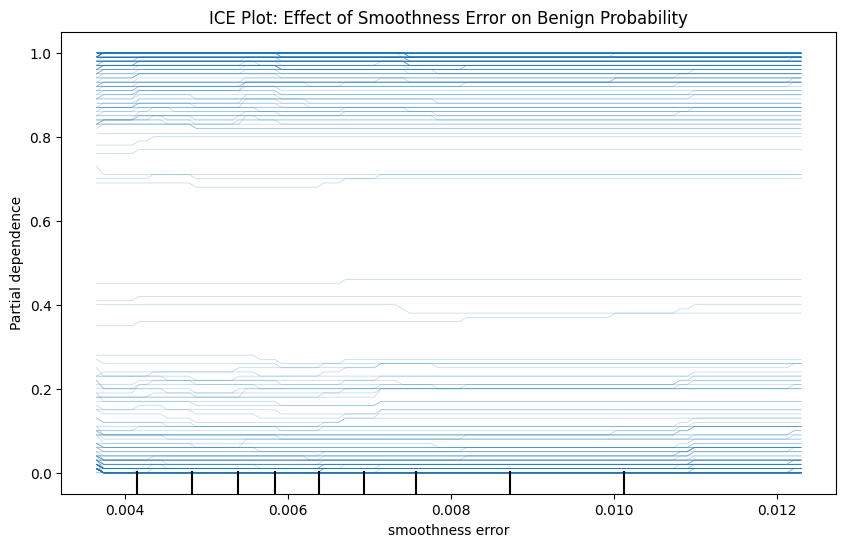

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fix, ax = plt.subplots(figsize=(10, 6))
display = PartialDependenceDisplay.from_estimator(
    model_bc, X_train, features=["smoothness error"], kind="individual", ax=ax
)

plt.title("ICE Plot: Effect of Smoothness Error on Benign Probability")
plt.show()

# Results & Findings

### Summary of Findings
* **TreeSHAP:** Highlights the specific feature values that pushed the model's prediction toward "Benign", showing the balance of features driving the outcome.
* **Anchors:** The model based its decision almost entirely on an oversimplified rule: `worst area <= 1031.50 AND worst texture <= 21.05 AND worst perimeter <= 124.65`. Meeting these three conditions gave the model 98% confidence in a Benign diagnosis, effectively blinding it to the other 27 features.
* **ICE Plot:** Confirms the model's strict thresholding behavior regarding `worst perimeter`. The probability of a benign diagnosis is kept high as long as this feature stays below the cutoff. If we change the primary feature to something like "smoothness error", we see that there is very little correlation to the probability of being a benign tumor --> hence, we can rely on the model but only to a certain degree.

### Argument for the Prosecution
**The model exhibited dangerous "tunnel vision," prioritizing arbitrary thresholds over holistic patient health.**

By anchoring its diagnosis on just three metrics (worst area, texture, and perimeter), the model demonstrated a severe flaw in its diagnostic logic. Because Patient X's measurements happened to fall just below these specific cutoffs, the algorithm acted as a rubber stamp for a "Benign" diagnosis, completely ignoring the remaining 27 complex medical indicators. A human oncologist looks at the whole picture; this model rigidly followed a simplistic rule, missing critical nuanced warning signs and delaying a life-saving biopsy. This proves the system is currently unsafe and dangerously overconfident in edge cases.